# sEEG Multi-Class CSP Analysis

This notebook implements a 4-class CSP (Common Spatial Pattern) pipeline:
1. Load all trials from 4 class folders in `dataset/`
2. Detect and remove bad channels (concatenated across all trials)
3. Apply notch + bandpass filtering and compute LMP
4. Build overlapping windows with class labels
5. Extract One-vs-Rest FBCSP features (HFB + LMP)
6. Visualize CSP spatial patterns and feature distributions

## Step 0 - Imports and Function Definitions
Define all preprocessing, CSP, and visualization functions.

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt, iirnotch
from pathlib import Path


def detect_bad_channels_stat(data, standard_range=(-500, 500)):
    """Detect bad sEEG channels using statistical features.

    Args:
        data: Array with shape (n_channels, n_samples).
        standard_range: Acceptable amplitude range in microvolts.
    """
    bad_channels_indices = []

    constant_mask = np.all(np.isclose(data, data[:, [0]], atol=1e-5), axis=1)
    constant_channels = np.where(constant_mask)[0]
    bad_channels_indices.extend(constant_channels)

    means = np.mean(data, axis=1)
    offset_mask = np.abs(means) > 20
    offset_channels = np.where(offset_mask)[0]
    bad_channels_indices.extend(offset_channels)

    outside_mask = np.any(
        (data < standard_range[0]) | (data > standard_range[1]),
        axis=1,
    )
    outside_channels = np.where(outside_mask)[0]
    bad_channels_indices.extend(outside_channels)

    unique_bad_channels = sorted(set(bad_channels_indices))

    print(f"Constant channels: {constant_channels}")
    print(f"Offset channels: {offset_channels}")
    print(f"Outside standard range: {outside_channels}")

    return unique_bad_channels


def bandpass_filter(data, low_freq, high_freq, fs=2000, order=4):
    """Apply a band-pass filter to extract a target frequency band.

    Args:
        data: 2D array with shape (n_channels, n_samples).
        low_freq: Low cutoff frequency in Hz.
        high_freq: High cutoff frequency in Hz.
        fs: Sampling rate in Hz (default: 2000).
        order: Filter order (default: 4).

    Returns:
        Filtered data with the same shape as input.
    """
    nyquist = fs / 2
    low = low_freq / nyquist
    high = high_freq / nyquist

    b, a = butter(order, [low, high], btype="band")
    filtered_data = filtfilt(b, a, data, axis=1)

    return filtered_data


def apply_notch_filter(data, freq=50, fs=2000, q=30):
    """Apply a notch filter to remove power-line interference.

    Args:
        data: 2D array with shape (n_channels, n_samples).
        freq: Frequency to remove in Hz (50 or 60 typically).
        fs: Sampling rate in Hz.
        q: Quality factor; higher values produce a narrower notch.

    Returns:
        Filtered data with the same shape as input.
    """
    nyquist = fs / 2
    w0 = freq / nyquist

    b, a = iirnotch(w0, q)
    filtered_data = filtfilt(b, a, data, axis=1)

    return filtered_data


def create_windows(data, window_size, stride):
    """Create overlapping windows from channel-by-time data.

    Args:
        data: 2D array with shape (n_channels, n_samples).
        window_size: Window length in samples.
        stride: Step between consecutive windows in samples.

    Returns:
        3D array with shape (n_windows, n_channels, window_size).
    """
    _, n_samples = data.shape
    windows = []
    for i in range(0, n_samples - window_size + 1, stride):
        windows.append(data[:, i : i + window_size])
    return np.array(windows)


def calculate_lmp(data, window_ms=250, fs=2000):
    """Calculate Local Motor Potential (LMP) as a running average.

    Args:
        data: 2D array with shape (n_channels, n_samples).
        window_ms: Window size for running average in milliseconds.
        fs: Sampling rate in Hz.

    Returns:
        LMP data with the same shape as input.
    """
    window_size = int(window_ms * fs / 1000)
    window = np.ones(window_size) / window_size
    lmp_data = np.apply_along_axis(
        lambda x: np.convolve(x, window, mode="same"),
        axis=1,
        arr=data,
    )
    return lmp_data


def filter_seeg_data(data, fs=2000):
    """Run the full sEEG filtering pipeline.

    Steps:
        1) Apply notch filtering to remove power-line noise.
        2) Apply band-pass filtering to obtain low/high frequency bands.
        3) Calculate Local Motor Potential (LMP) as running average.
    """
    data_no_notch = apply_notch_filter(data, freq=50, fs=fs)
    lfb_result = bandpass_filter(data_no_notch, 0.5, 30, fs)
    hfb_result = bandpass_filter(data_no_notch, 80, 200, fs)
    lmp_result = calculate_lmp(data_no_notch, window_ms=250, fs=fs)
    return lfb_result, hfb_result, lmp_result


def compute_covariance_matrices(windows, labels):
    """Compute normalized covariance matrices for each class.

    Args:
        windows: 3D array (n_windows, n_channels, n_samples).
        labels: 1D array of class labels (0 or 1).

    Returns:
        Tuple of (cov_class0, cov_class1) covariance matrices.
    """
    classes = np.unique(labels)
    cov_matrices = []
    for c in classes:
        class_windows = windows[labels == c]
        cov_sum = np.zeros((class_windows.shape[1], class_windows.shape[1]))
        for w in class_windows:
            cov_sum += np.dot(w, w.T)
        cov_matrices.append(cov_sum / np.trace(cov_sum))
    return cov_matrices[0], cov_matrices[1]


def compute_csp_filters(cov0, cov1, n_components=4):
    """Compute CSP spatial filters from two covariance matrices.

    Args:
        cov0: Covariance matrix for class 0.
        cov1: Covariance matrix for class 1.
        n_components: Number of filter pairs to return (default 4).

    Returns:
        Spatial filter matrix (n_components, n_channels).
    """
    cov_sum = cov0 + cov1
    eigvals, eigvecs = np.linalg.eigh(cov_sum)
    eigvals = eigvals[::-1]
    eigvecs = eigvecs[:, ::-1]

    whitening_matrix = eigvecs @ np.diag(1.0 / np.sqrt(eigvals)) @ eigvecs.T
    cov0_white = whitening_matrix @ cov0 @ whitening_matrix.T

    eigvals_white, eigvecs_white = np.linalg.eigh(cov0_white)
    eigvals_white = eigvals_white[::-1]
    eigvecs_white = eigvecs_white[:, ::-1]

    csp_filters = eigvecs_white.T @ whitening_matrix

    first_last = []
    half = n_components // 2
    for i in range(half):
        first_last.append(i)
    for i in range(-half, 0):
        first_last.append(i)

    return csp_filters[first_last]


def apply_csp(windows, csp_filters):
    """Apply CSP filters and return log-variance features.

    Args:
        windows: 3D array (n_windows, n_channels, n_samples).
        csp_filters: Spatial filter matrix (n_components, n_channels).

    Returns:
        Log-variance features (n_windows, n_components).
    """
    projected = np.einsum("fc,wcs->wfs", csp_filters, windows)
    variances = np.var(projected, axis=2)
    log_var = np.log(variances)
    return log_var


def extract_ovr_fbcsp_features(hfb_windows, lmp_windows, labels, n_classes=4, n_components=4):
    """Extract One-vs-Rest Filter Bank CSP features for multi-class classification.

    For each class i, builds a binary split: class i vs all other classes.
    Computes CSP filters on HFB and LMP for each binary split,
    then concatenates all log-variance features.

    Args:
        hfb_windows: HFB windowed data (n_windows, n_channels, n_samples).
        lmp_windows: LMP windowed data (n_windows, n_channels, n_samples).
        labels: Class labels (n_windows,) with values in [0, n_classes-1].
        n_classes: Number of classes (default 4).
        n_components: Number of CSP filter pairs per band per OvR classifier.

    Returns:
        Dictionary with:
            'features': (n_windows, n_classes * 2_bands * n_components)
            'filters': dict keyed by (ovr_class, band_name)
            'band_names': list of band names
    """
    bands = {"HFB": hfb_windows, "LMP": lmp_windows}
    band_names = list(bands.keys())
    all_features = []
    all_filters = {}

    for cls in range(n_classes):
        binary_labels = (labels == cls).astype(int)

        for band_name, band_windows in bands.items():
            cov0, cov1 = compute_covariance_matrices(band_windows, binary_labels)
            filters = compute_csp_filters(cov0, cov1, n_components=n_components)
            features = apply_csp(band_windows, filters)
            all_features.append(features)
            all_filters[(cls, band_name)] = filters

    combined_features = np.hstack(all_features)
    return {
        "features": combined_features,
        "filters": all_filters,
        "band_names": band_names,
    }


def visualize_csp_filters(csp_filters, title="", step=50):
    """Visualize CSP spatial patterns as channel weight bar plots.

    Args:
        csp_filters: Filter matrix (n_components, n_channels).
        title: Title for the figure.
        step: Only show every `step`-th channel.
    """
    n_components = csp_filters.shape[0]
    n_channels = csp_filters.shape[1]

    fig, axes = plt.subplots(1, n_components, figsize=(4 * n_components, 4))
    if n_components == 1:
        axes = [axes]

    channel_indices = np.arange(0, n_channels, step)
    for i, ax in enumerate(axes):
        weights = csp_filters[i, channel_indices]
        colors_bar = ["red" if w < 0 else "blue" for w in weights]
        ax.bar(range(len(channel_indices)), weights, color=colors_bar)
        ax.set_title(f"Filter {i + 1}")
        ax.set_xlabel(f"Channel (every {step}-th)")
        ax.set_ylabel("Weight")
        ax.axhline(y=0, color="black", linewidth=0.5)

    fig.suptitle(title, fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()


def visualize_csp_features_multiclass(features, labels, band_names, class_names):
    """Visualize CSP log-variance features for all classes.

    Args:
        features: CSP features (n_windows, n_components_total).
        labels: Class labels (n_windows,).
        band_names: List of band names used.
        class_names: List of class display names.
    """
    n_components = features.shape[1]
    n_classes = len(class_names)
    n_bands = len(band_names)
    features_per_ovr = n_components // n_classes

    n_cols = min(n_components, 4)
    n_rows = int(np.ceil(n_components / n_cols))

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 3 * n_rows))
    if n_components == 1:
        axes = np.array([axes])
    axes = axes.flatten()

    cmap = plt.cm.tab10

    for i in range(n_components):
        ax = axes[i]
        ovr_idx = i // features_per_ovr
        feature_idx_in_ovr = i % features_per_ovr
        band_idx = feature_idx_in_ovr // (features_per_ovr // n_bands) if n_bands > 1 else 0
        band_idx = min(band_idx, n_bands - 1)

        for c in range(n_classes):
            ax.hist(features[labels == c, i], bins=15, alpha=0.5,
                    label=class_names[c], color=cmap(c))

        ax.set_title(f"Class {ovr_idx} vs Rest - {band_names[band_idx]} (F{feature_idx_in_ovr + 1})")
        ax.set_xlabel("Log-Variance")
        ax.set_ylabel("Count")
        ax.legend(fontsize=7)

    for j in range(i + 1, len(axes)):
        axes[j].axis("off")

    plt.tight_layout()
    plt.show()


np.set_printoptions(precision=4, suppress=True)
plt.rcParams["figure.figsize"] = (12, 4)

## Step 1 - Load All Class Data
Load `.npz` files from each class folder. Each file is one trial with shape `(channels, samples)`.

In [10]:
dataset_dir = Path('dataset')

class_configs = [
    ('class_1_关一下灯', '关一下灯'),
    ('class_2_我冷了', '我冷了'),
    ('class_3_我想出门走走', '我想出门走走'),
    ('class_4_现在几点了', '现在几点了'),
]

class_names = [cfg[1] for cfg in class_configs]
all_trials = []

for cls_idx, (folder_name, display_name) in enumerate(class_configs):
    folder = dataset_dir / folder_name
    npz_files = sorted(folder.glob('*.npz'))
    trials = []
    for f in npz_files:
        data = np.load(f)
        arr = data[data.files[0]]
        if arr.shape[0] > arr.shape[1]:
            arr = arr.T
        trials.append(arr)
    all_trials.append(trials)
    print(f'Class {cls_idx} ({display_name}): {len(trials)} trials, shape {trials[0].shape if trials else "N/A"}')

n_classes = len(all_trials)
n_channels = all_trials[0][0].shape[0]
print(f'\nTotal: {n_classes} classes, {n_channels} channels, {sum(len(t) for t in all_trials)} trials')

Class 0 (关一下灯): 20 trials, shape (276, 8480)
Class 1 (我冷了): 20 trials, shape (276, 8420)
Class 2 (我想出门走走): 20 trials, shape (276, 8400)
Class 3 (现在几点了): 20 trials, shape (276, 8400)

Total: 4 classes, 276 channels, 80 trials


## Step 2 - Detect and Remove Bad Channels
Concatenate all trials along the time axis to get a robust estimate of bad channels, then remove them from every trial.

In [11]:
all_trials_flat = [trial for cls_trials in all_trials for trial in cls_trials]
concatenated = np.concatenate(all_trials_flat, axis=1)
print(f'Concatenated data shape: {concatenated.shape}')

bad_indices = detect_bad_channels_stat(concatenated)
print(f'\nBad channels ({len(bad_indices)} total): {bad_indices}')

keep_mask = np.ones(n_channels, dtype=bool)
keep_mask[bad_indices] = False

for cls_idx in range(n_classes):
    for trial_idx in range(len(all_trials[cls_idx])):
        all_trials[cls_idx][trial_idx] = all_trials[cls_idx][trial_idx][keep_mask]

n_channels_clean = all_trials[0][0].shape[0]
print(f'\nChannels after removal: {n_channels_clean} (removed {len(bad_indices)})')

Concatenated data shape: (276, 674560)
Constant channels: [272 273 274 275]
Offset channels: [256 257 258 259 260 261 262 263 264 265 266 267 272 273 274]
Outside standard range: [  0   1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  24
  25  26  27  30  31  35  39  40  41  42  43  44  45  46  47  49  50  51
  52  53  54  55  56  57  58  59  60  61  62  63  64  65  73  74  75  77
  78  79  80  81  82  85  94  95  96  97  98  99 100 101 102 103 104 105
 106 107 108 109 110 111 112 113 114 115 116 117 118 119 120 121 122 123
 124 125 126 127 128 129 130 131 132 133 134 135 136 137 138 139 140 141
 142 143 144 145 146 147 148 149 150 151 152 153 154 155 156 157 158 159
 160 161 162 163 164 165 166 167 168 169 170 171 172 173 174 175 176 177
 178 179 180 181 182 183 184 185 186 187 188 189 190 191 192 193 194 195
 196 197 198 199 200 201 202 203 204 205 206 207 208 209 210 211 212 213
 214 215 216 217 218 219 220 221 222 223 224 225 226 227 228 229 230 231
 232 233 234 235 2

## Step 3 - Filter All Trials
Apply the full preprocessing pipeline (notch -> HFB/LFB -> LMP) to every trial.

In [12]:
fs = 2000

all_hfb_trials = []
all_lmp_trials = []

for cls_idx in range(n_classes):
    cls_hfb = []
    cls_lmp = []
    for trial in all_trials[cls_idx]:
        _, hfb, lmp = filter_seeg_data(trial, fs=fs)
        cls_hfb.append(hfb)
        cls_lmp.append(lmp)
    all_hfb_trials.append(cls_hfb)
    all_lmp_trials.append(cls_lmp)

print(f'HFB trial shapes: {[t.shape for t in all_hfb_trials[0][:3]]}...')
print(f'LMP trial shapes: {[t.shape for t in all_lmp_trials[0][:3]]}...')

HFB trial shapes: [(38, 8480), (38, 8400), (38, 8400)]...
LMP trial shapes: [(38, 8480), (38, 8400), (38, 8400)]...


## Step 4 - Create Overlapping Windows with Labels
Cut each trial into overlapping windows and assign the trial's class label to all its windows.

In [13]:
window_size = 250
stride = 225

hfb_windows_list = []
lmp_windows_list = []
labels_list = []

for cls_idx in range(n_classes):
    for trial_hfb, trial_lmp in zip(all_hfb_trials[cls_idx], all_lmp_trials[cls_idx]):
        hfb_w = create_windows(trial_hfb, window_size=window_size, stride=stride)
        lmp_w = create_windows(trial_lmp, window_size=window_size, stride=stride)
        n_w = len(hfb_w)
        hfb_windows_list.append(hfb_w)
        lmp_windows_list.append(lmp_w)
        labels_list.append(np.full(n_w, cls_idx, dtype=int))

hfb_windows = np.concatenate(hfb_windows_list, axis=0)
lmp_windows = np.concatenate(lmp_windows_list, axis=0)
labels = np.concatenate(labels_list, axis=0)

print(f'Total windows: {len(labels)}')
print(f'HFB windows shape: {hfb_windows.shape}')
print(f'LMP windows shape: {lmp_windows.shape}')
print(f'\nWindows per class:')
for cls_idx, name in enumerate(class_names):
    count = np.sum(labels == cls_idx)
    print(f'  Class {cls_idx} ({name}): {count} windows')

Total windows: 2960
HFB windows shape: (2960, 38, 250)
LMP windows shape: (2960, 38, 250)

Windows per class:
  Class 0 (关一下灯): 740 windows
  Class 1 (我冷了): 740 windows
  Class 2 (我想出门走走): 740 windows
  Class 3 (现在几点了): 740 windows


## Step 5 - Multi-Class CSP (One-vs-Rest)
For each of the 4 classes, build a binary CSP classifier (class i vs all others) on both HFB and LMP bands.
This yields 4 OvR classifiers x 2 bands x 4 components = 32 features per window.

In [14]:
n_components = 4

fbcsp_result = extract_ovr_fbcsp_features(
    hfb_windows, lmp_windows, labels,
    n_classes=n_classes, n_components=n_components
)

print(f'Combined FBCSP features shape: {fbcsp_result["features"].shape}')
print(f'Expected: ({len(labels)} windows, {n_classes} classes x {len(fbcsp_result["band_names"])} bands x {n_components} components)')
print(f'\nFilters stored for:')
for key in fbcsp_result["filters"]:
    print(f'  {key}: shape {fbcsp_result["filters"][key].shape}')

Combined FBCSP features shape: (2960, 32)
Expected: (2960 windows, 4 classes x 2 bands x 4 components)

Filters stored for:
  (0, 'HFB'): shape (4, 38)
  (0, 'LMP'): shape (4, 38)
  (1, 'HFB'): shape (4, 38)
  (1, 'LMP'): shape (4, 38)
  (2, 'HFB'): shape (4, 38)
  (2, 'LMP'): shape (4, 38)
  (3, 'HFB'): shape (4, 38)
  (3, 'LMP'): shape (4, 38)


## Step 6 - Visualize CSP Results
1. **Spatial patterns**: Channel weights for each OvR classifier and band.
2. **Feature histograms**: Log-variance distribution of all 4 classes per feature component.

C:\Users\hilin\AppData\Local\Temp\ipykernel_8328\1043794868.py:280: UserWarning: Glyph 20851 (\N{CJK UNIFIED IDEOGRAPH-5173}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\hilin\AppData\Local\Temp\ipykernel_8328\1043794868.py:280: UserWarning: Glyph 19968 (\N{CJK UNIFIED IDEOGRAPH-4E00}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\hilin\AppData\Local\Temp\ipykernel_8328\1043794868.py:280: UserWarning: Glyph 19979 (\N{CJK UNIFIED IDEOGRAPH-4E0B}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\hilin\AppData\Local\Temp\ipykernel_8328\1043794868.py:280: UserWarning: Glyph 28783 (\N{CJK UNIFIED IDEOGRAPH-706F}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


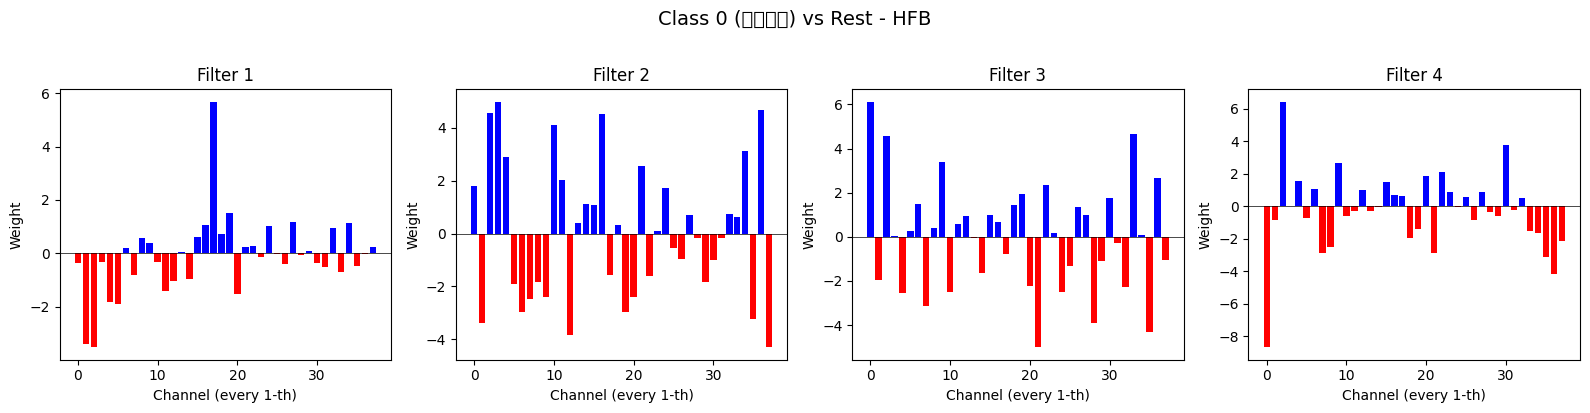

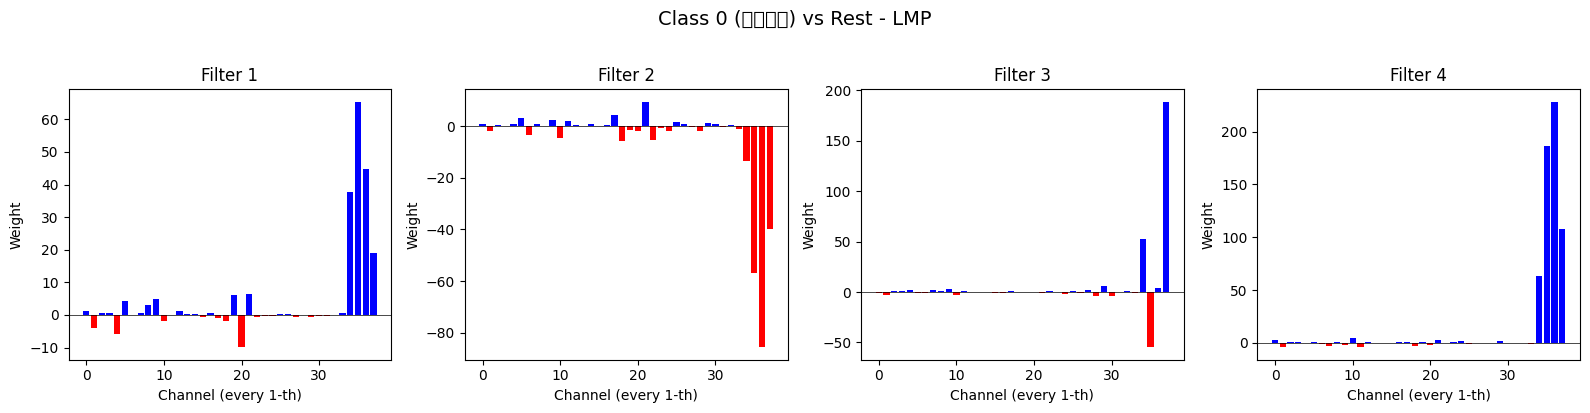

C:\Users\hilin\AppData\Local\Temp\ipykernel_8328\1043794868.py:280: UserWarning: Glyph 25105 (\N{CJK UNIFIED IDEOGRAPH-6211}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\hilin\AppData\Local\Temp\ipykernel_8328\1043794868.py:280: UserWarning: Glyph 20919 (\N{CJK UNIFIED IDEOGRAPH-51B7}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\hilin\AppData\Local\Temp\ipykernel_8328\1043794868.py:280: UserWarning: Glyph 20102 (\N{CJK UNIFIED IDEOGRAPH-4E86}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


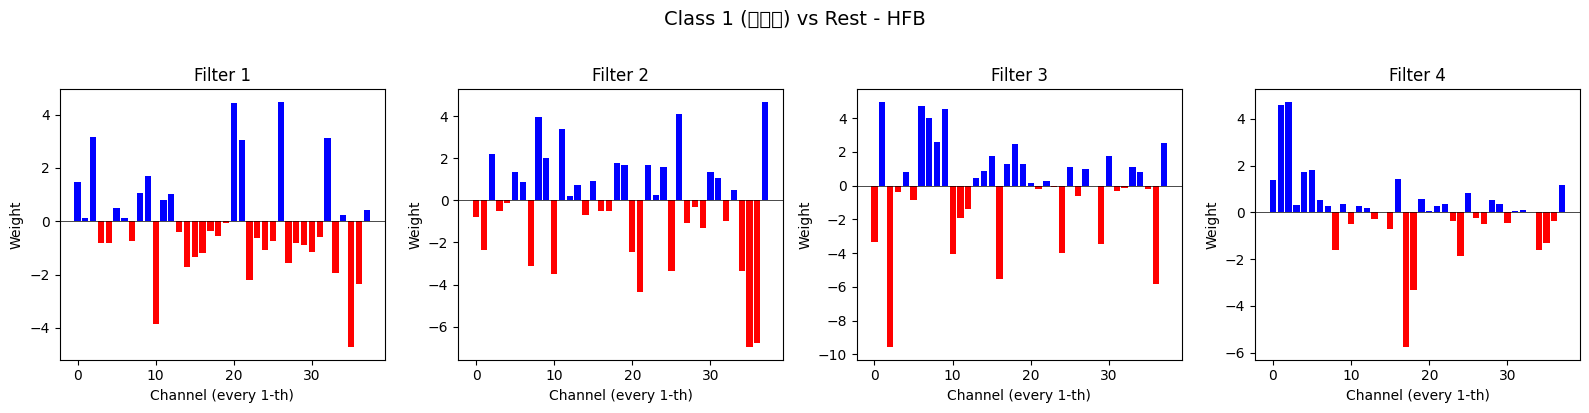

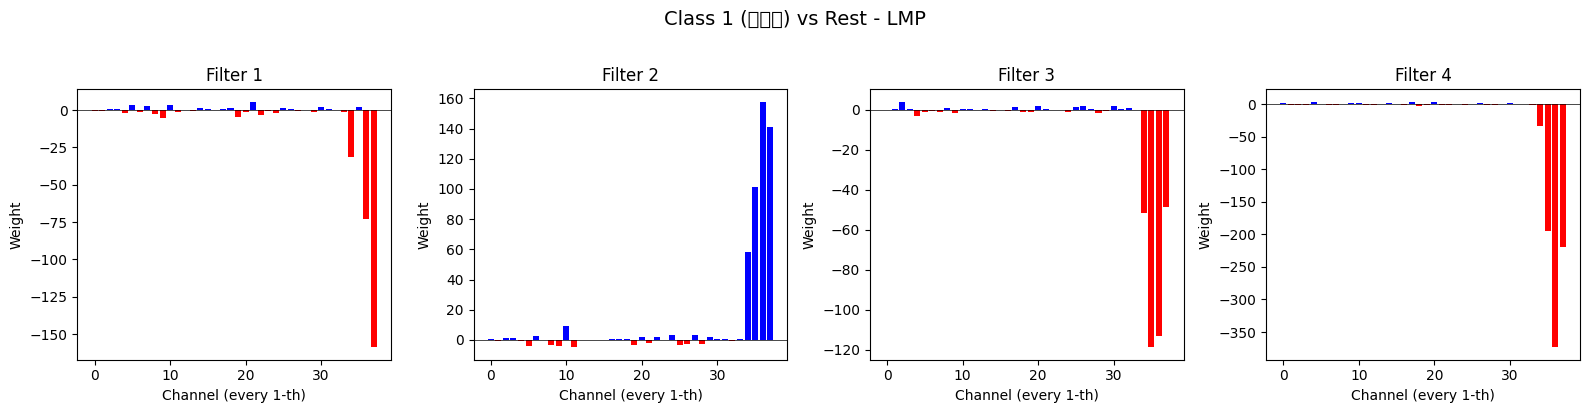

C:\Users\hilin\AppData\Local\Temp\ipykernel_8328\1043794868.py:280: UserWarning: Glyph 24819 (\N{CJK UNIFIED IDEOGRAPH-60F3}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\hilin\AppData\Local\Temp\ipykernel_8328\1043794868.py:280: UserWarning: Glyph 20986 (\N{CJK UNIFIED IDEOGRAPH-51FA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\hilin\AppData\Local\Temp\ipykernel_8328\1043794868.py:280: UserWarning: Glyph 38376 (\N{CJK UNIFIED IDEOGRAPH-95E8}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\hilin\AppData\Local\Temp\ipykernel_8328\1043794868.py:280: UserWarning: Glyph 36208 (\N{CJK UNIFIED IDEOGRAPH-8D70}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


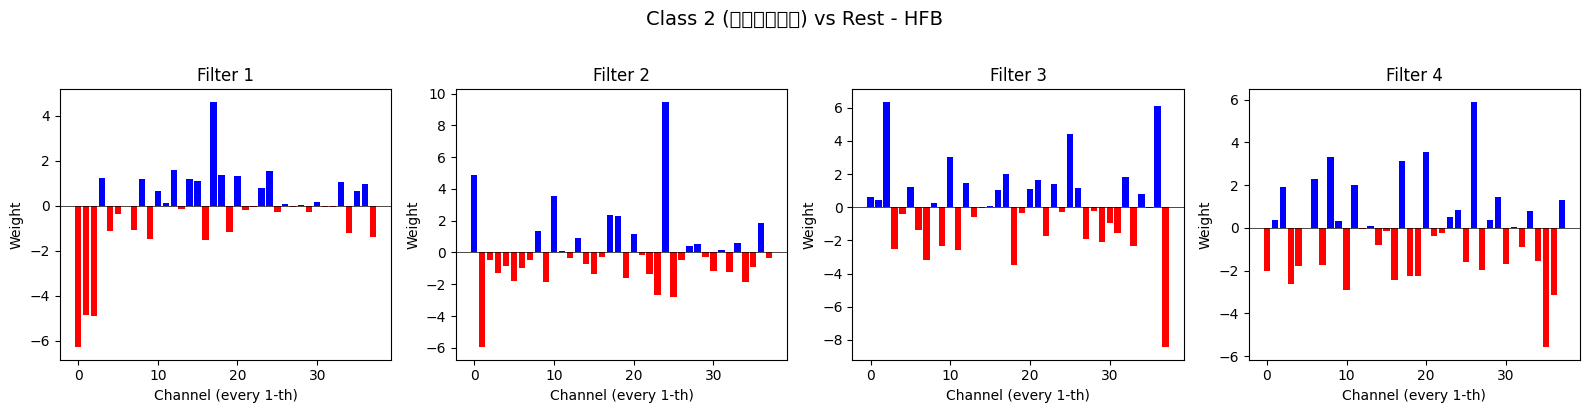

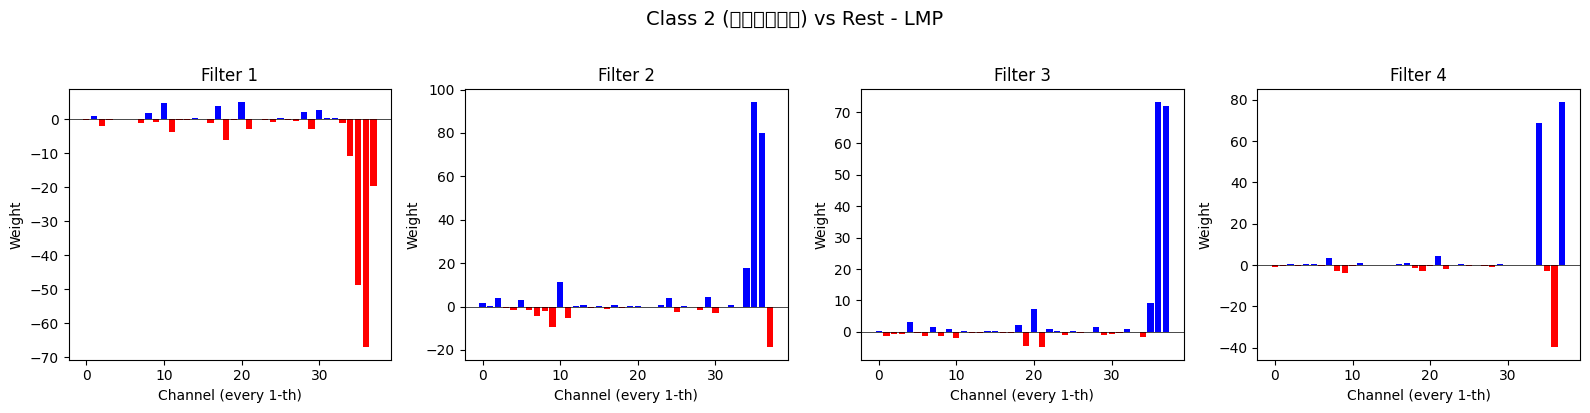

C:\Users\hilin\AppData\Local\Temp\ipykernel_8328\1043794868.py:280: UserWarning: Glyph 29616 (\N{CJK UNIFIED IDEOGRAPH-73B0}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\hilin\AppData\Local\Temp\ipykernel_8328\1043794868.py:280: UserWarning: Glyph 22312 (\N{CJK UNIFIED IDEOGRAPH-5728}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\hilin\AppData\Local\Temp\ipykernel_8328\1043794868.py:280: UserWarning: Glyph 20960 (\N{CJK UNIFIED IDEOGRAPH-51E0}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\hilin\AppData\Local\Temp\ipykernel_8328\1043794868.py:280: UserWarning: Glyph 28857 (\N{CJK UNIFIED IDEOGRAPH-70B9}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


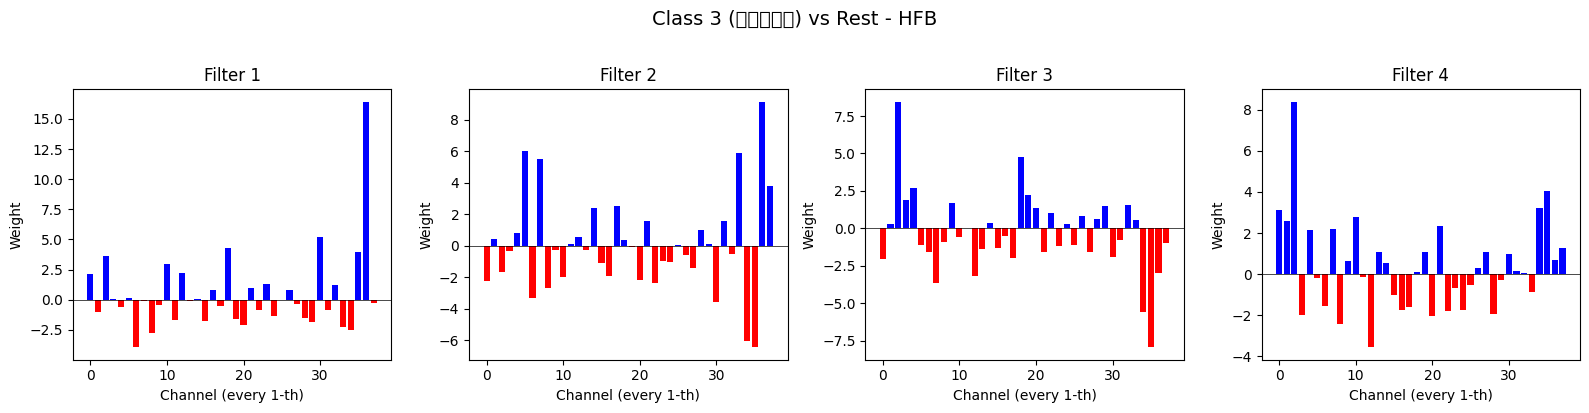

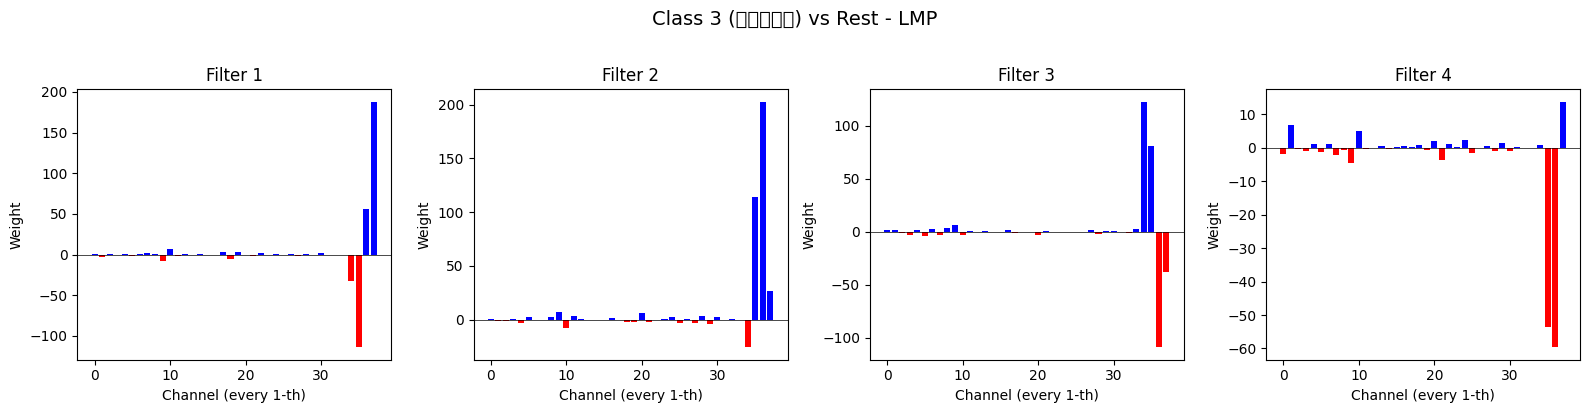

In [15]:
for cls_idx in range(n_classes):
    for band_name in fbcsp_result["band_names"]:
        filters = fbcsp_result["filters"][(cls_idx, band_name)]
        title = f"Class {cls_idx} ({class_names[cls_idx]}) vs Rest - {band_name}"
        step = max(1, n_channels_clean // 20)
        visualize_csp_filters(filters, title=title, step=step)

C:\Users\hilin\AppData\Local\Temp\ipykernel_8328\1043794868.py:327: UserWarning: Glyph 20851 (\N{CJK UNIFIED IDEOGRAPH-5173}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\hilin\AppData\Local\Temp\ipykernel_8328\1043794868.py:327: UserWarning: Glyph 19968 (\N{CJK UNIFIED IDEOGRAPH-4E00}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\hilin\AppData\Local\Temp\ipykernel_8328\1043794868.py:327: UserWarning: Glyph 19979 (\N{CJK UNIFIED IDEOGRAPH-4E0B}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\hilin\AppData\Local\Temp\ipykernel_8328\1043794868.py:327: UserWarning: Glyph 28783 (\N{CJK UNIFIED IDEOGRAPH-706F}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\hilin\AppData\Local\Temp\ipykernel_8328\1043794868.py:327: UserWarning: Glyph 25105 (\N{CJK UNIFIED IDEOGRAPH-6211}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\hilin\AppData\Local\Temp\ipykernel_8328\1043794868.py:327: UserWarning: Glyph 20919 (\

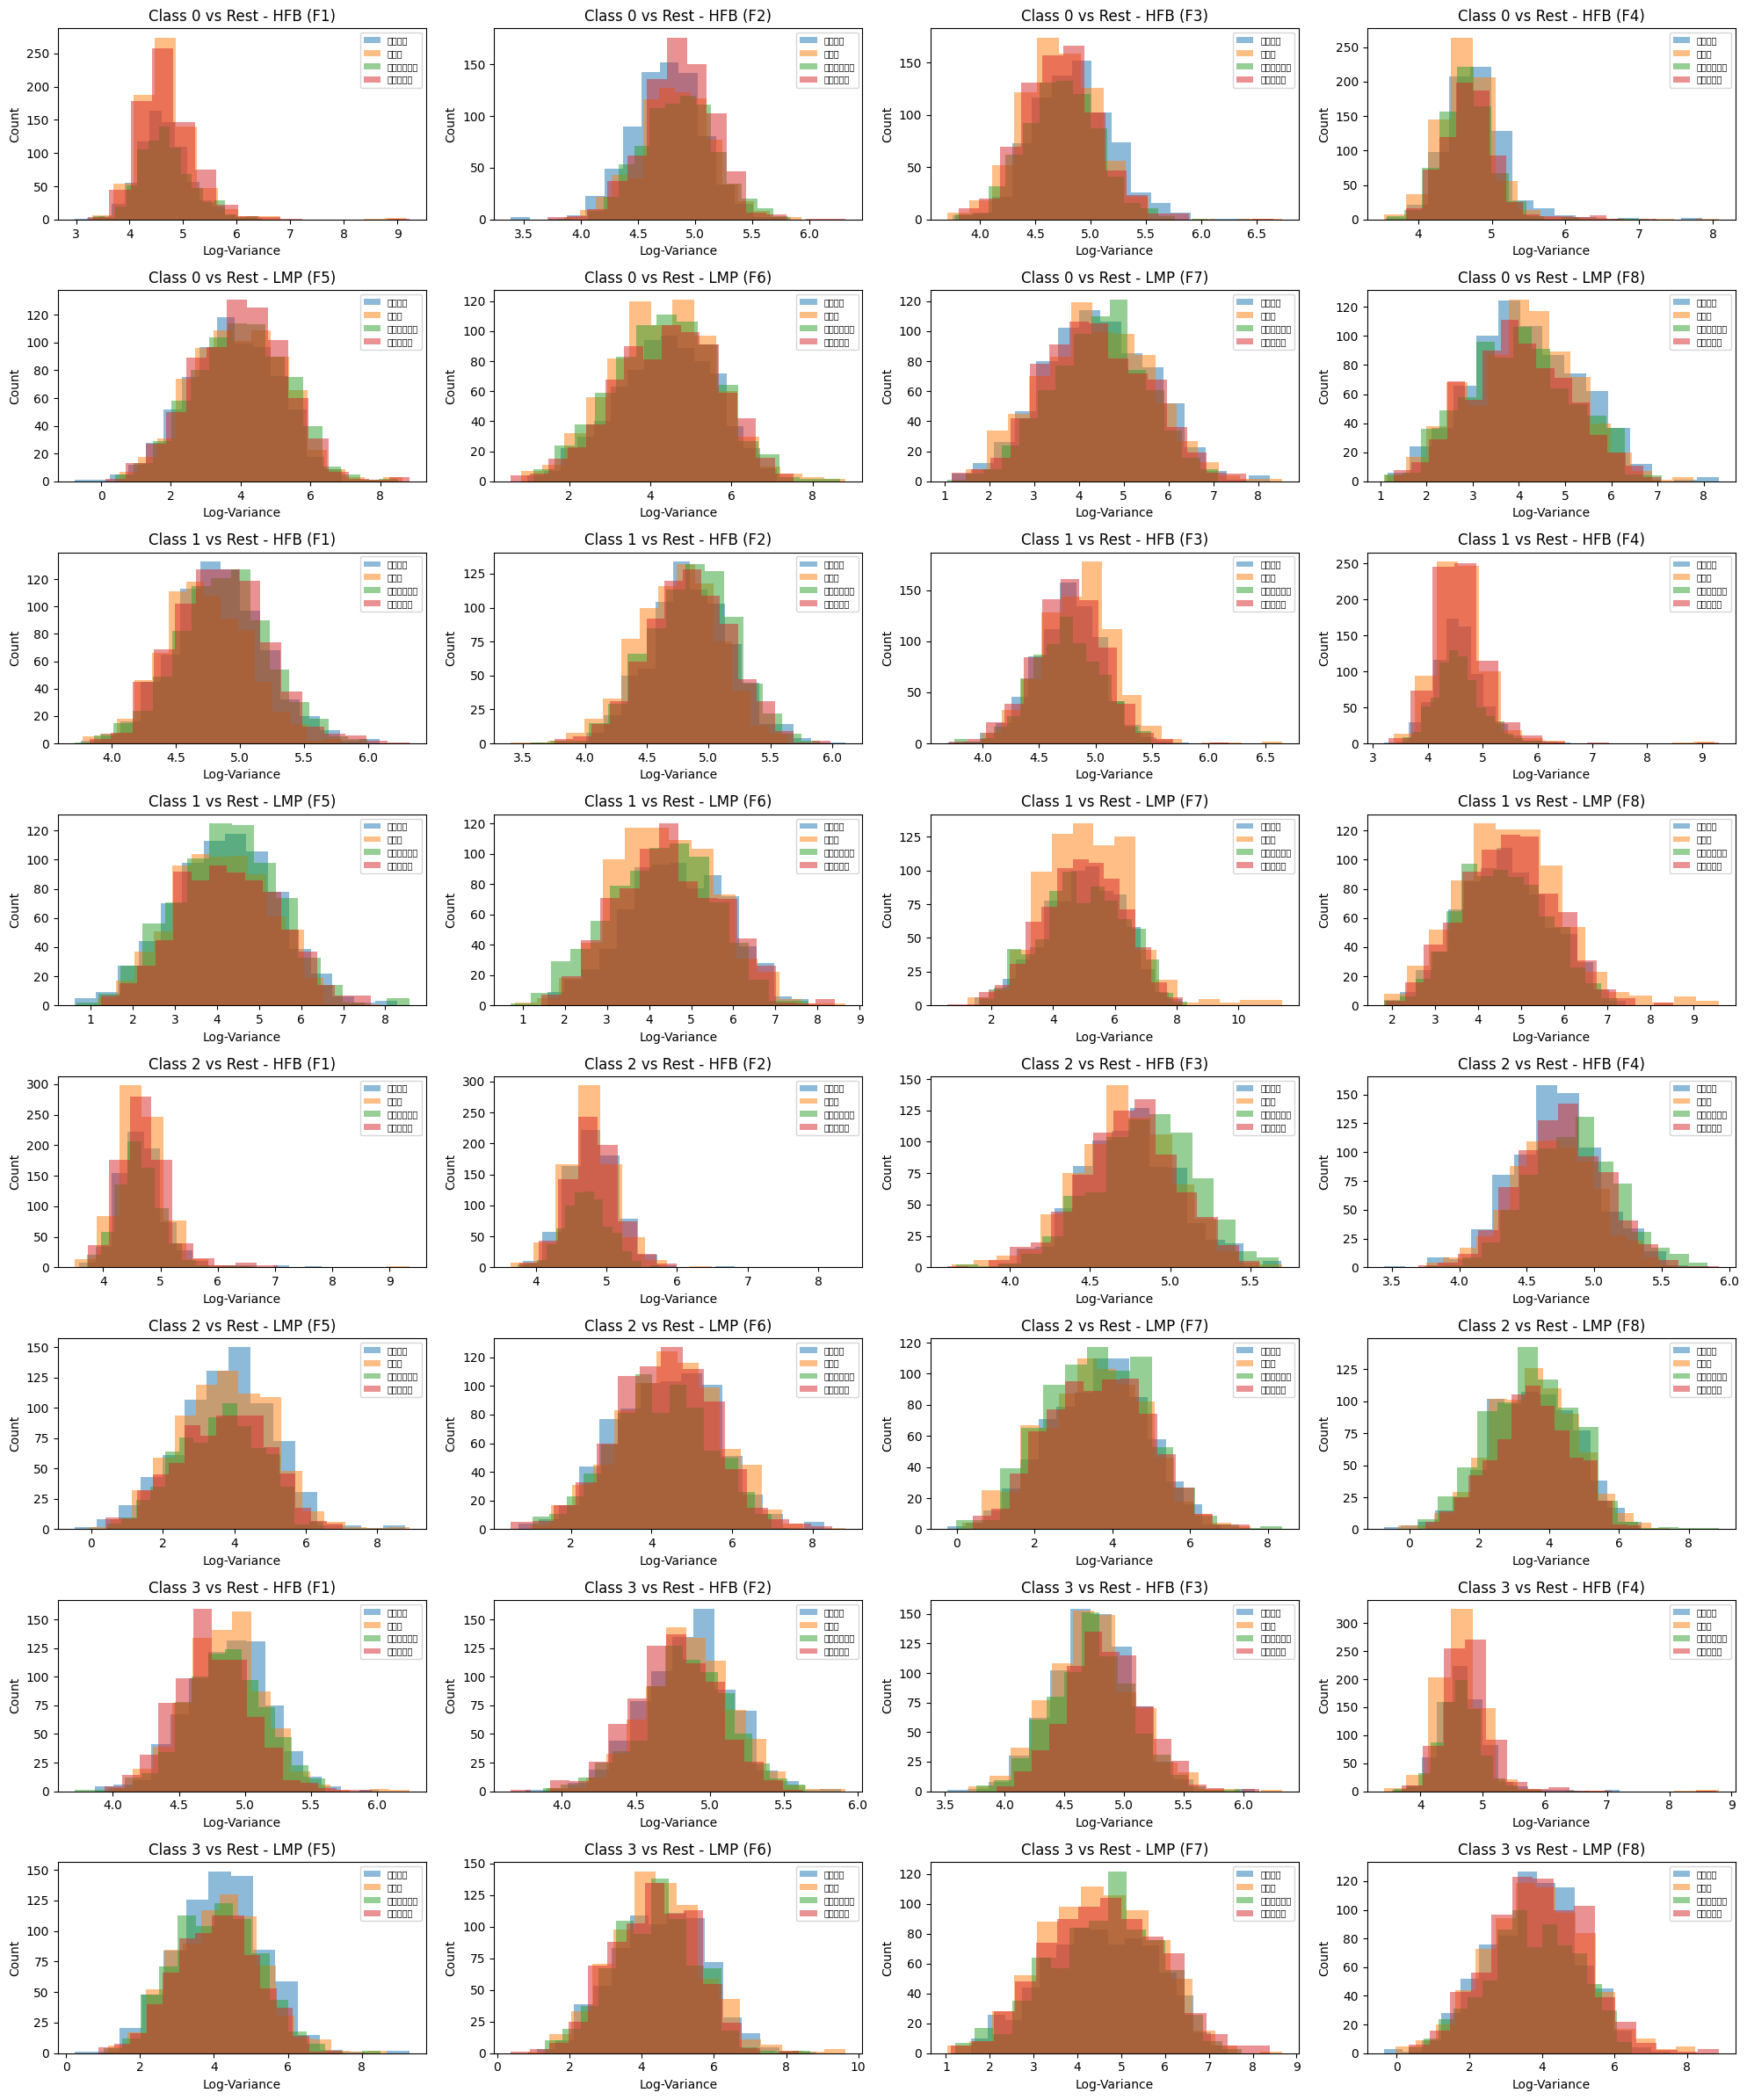

In [16]:
visualize_csp_features_multiclass(
    fbcsp_result["features"], labels,
    fbcsp_result["band_names"], class_names
)

## Next Extensions (Optional)
The extracted FBCSP features can now be fed into a classifier:
- `fbcsp_result["features"]` → feature matrix (n_windows, 32)
- `labels` → target labels (n_windows,)
- Add cross-validation, train/test split, and accuracy reporting.

## Step 7 - Feature Selection
Apply three algorithmic feature selection methods to identify the most discriminative feature subsets:
1. **Mutual Information (MI)** - Filter-based ranking by information-theoretic dependency
2. **LASSO** - L1-regularized multinomial logistic regression for sparse feature selection
3. **Genetic Algorithm (GA)** - Wrapper-based evolutionary search using LDA fitness

In [ ]:
from sklearn.feature_selection import mutual_info_classif
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
import random
import copy

In [ ]:
n_total_features = fbcsp_result["features"].shape[1]
n_classes_fs = n_classes
band_names = fbcsp_result["band_names"]


def get_feature_names(n_classes, band_names, n_components):
    names = []
    for cls in range(n_classes):
        for band in band_names:
            for c in range(n_components):
                names.append(f"Cls{cls}-{band}-CSP{c+1}")
    return names


feature_names = get_feature_names(n_classes_fs, band_names, n_components)


def select_features_mi(features, labels, n_features=16):
    mi_scores = mutual_info_classif(features, labels, random_state=42)
    top_indices = np.argsort(mi_scores)[::-1][:n_features]
    top_indices = np.sort(top_indices)
    return mi_scores, top_indices


def select_features_lasso(features, labels, alpha=0.01):
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(features)
    clf = LogisticRegression(
        penalty="l1", solver="saga", C=1.0 / alpha,
        multi_class="multinomial", max_iter=5000, random_state=42
    )
    clf.fit(X_scaled, labels)
    coef_mean = np.mean(np.abs(clf.coef_), axis=0)
    selected = np.where(np.any(clf.coef_ != 0, axis=0))[0]
    selected = np.sort(selected)
    return coef_mean, selected


def _ga_fitness(chromosome, features, labels, n_cv_folds=3):
    selected = np.where(chromosome == 1)[0]
    if len(selected) < n_classes:
        return 0.0
    X = features[:, selected]
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    clf = LinearDiscriminantAnalysis()
    cv = StratifiedKFold(n_splits=n_cv_folds, shuffle=True, random_state=42)
    scores = cross_val_score(clf, X_scaled, labels, cv=cv, scoring="accuracy")
    return scores.mean()


def select_features_ga(features, labels, n_generations=50, pop_size=50, n_features=16, n_cv_folds=3):
    n_feats = features.shape[1]
    mutation_rate = 1.0 / n_feats
    elite_count = 2

    def create_individual():
        ind = np.zeros(n_feats, dtype=int)
        idx = np.random.choice(n_feats, size=n_features, replace=False)
        ind[idx] = 1
        return ind

    population = [create_individual() for _ in range(pop_size)]
    fitnesses = [_ga_fitness(ind, features, labels, n_cv_folds) for ind in population]
    best_idx = np.argmax(fitnesses)
    best_individual = population[best_idx].copy()
    best_fitness = fitnesses[best_idx]
    history = [best_fitness]
    selection_counts = np.zeros(n_feats)

    for gen in range(n_generations):
        ranked = sorted(zip(fitnesses, population), key=lambda x: x[0], reverse=True)
        new_population = [ind.copy() for _, ind in ranked[:elite_count]]

        while len(new_population) < pop_size:
            tournament_size = 3
            candidates = random.sample(list(zip(fitnesses, population)), tournament_size)
            p1 = max(candidates, key=lambda x: x[0])[1].copy()
            candidates = random.sample(list(zip(fitnesses, population)), tournament_size)
            p2 = max(candidates, key=lambda x: x[0])[1].copy()

            mask = np.random.rand(n_feats) < 0.5
            child = np.where(mask, p1, p2)

            mutation = np.random.rand(n_feats) < mutation_rate
            child[mutation] = 1 - child[mutation]

            n_selected = child.sum()
            if n_selected == 0:
                idx = np.random.randint(n_feats)
                child[idx] = 1
            elif n_selected > n_features * 2:
                ones = np.where(child == 1)[0]
                to_remove = np.random.choice(ones, size=n_selected - n_features, replace=False)
                child[to_remove] = 0

            new_population.append(child)

        population = new_population
        fitnesses = [_ga_fitness(ind, features, labels, n_cv_folds) for ind in population]
        gen_best_idx = np.argmax(fitnesses)
        if fitnesses[gen_best_idx] > best_fitness:
            best_fitness = fitnesses[gen_best_idx]
            best_individual = population[gen_best_idx].copy()
        history.append(best_fitness)

        for ind in population:
            selection_counts += ind

    selection_freq = selection_counts / (pop_size * n_generations)
    selected = np.where(best_individual == 1)[0]
    selected = np.sort(selected)
    return selection_freq, selected, history


def plot_feature_selection_results(mi_scores, mi_selected, lasso_coefs, lasso_selected, ga_freq, ga_selected, feature_names):
    n = len(feature_names)
    fig, axes = plt.subplots(3, 1, figsize=(16, 12))

    x = np.arange(n)
    colors = ["red" if i in mi_selected else "steelblue" for i in x]
    axes[0].bar(x, mi_scores, color=colors)
    axes[0].set_title(f"Mutual Information Scores (selected: {len(mi_selected)}/{n})", fontsize=12)
    axes[0].set_ylabel("MI Score")
    axes[0].set_xticks(x)
    axes[0].set_xticklabels(feature_names, rotation=90, fontsize=7)
    axes[0].axhline(y=np.sort(mi_scores)[::-1][len(mi_selected)-1], color="green", linestyle="--", alpha=0.5, label="Selection threshold")
    axes[0].legend()

    colors = ["red" if i in lasso_selected else "steelblue" for i in x]
    axes[1].bar(x, lasso_coefs, color=colors)
    axes[1].set_title(f"LASSO Coefficients (selected: {len(lasso_selected)}/{n})", fontsize=12)
    axes[1].set_ylabel("Mean |Coefficient|")
    axes[1].set_xticks(x)
    axes[1].set_xticklabels(feature_names, rotation=90, fontsize=7)
    axes[1].axhline(y=0, color="black", linewidth=0.5)

    colors = ["red" if i in ga_selected else "steelblue" for i in x]
    axes[2].bar(x, ga_freq, color=colors)
    axes[2].set_title(f"GA Selection Frequency (selected: {len(ga_selected)}/{n})", fontsize=12)
    axes[2].set_ylabel("Selection Frequency")
    axes[2].set_xlabel("Feature")
    axes[2].set_xticks(x)
    axes[2].set_xticklabels(feature_names, rotation=90, fontsize=7)

    plt.tight_layout()
    plt.show()


def evaluate_feature_subset(features, labels, selected_indices, n_folds=5):
    if len(selected_indices) == 0:
        return 0.0
    X = features[:, selected_indices]
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    clf = LinearDiscriminantAnalysis()
    cv = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=42)
    scores = cross_val_score(clf, X_scaled, labels, cv=cv, scoring="accuracy")
    return scores.mean(), scores.std()

### 7.1 - Run All Three Feature Selection Methods

In [ ]:
N_FEATURES_TARGET = 16
features = fbcsp_result["features"]

print("=" * 60)
print("Running Mutual Information selection...")
mi_scores, mi_selected = select_features_mi(features, labels, n_features=N_FEATURES_TARGET)
print(f"  Selected {len(mi_selected)} features: {[feature_names[i] for i in mi_selected]}")

print("\nRunning LASSO selection...")
lasso_coefs, lasso_selected = select_features_lasso(features, labels, alpha=0.01)
print(f"  Selected {len(lasso_selected)} features: {[feature_names[i] for i in lasso_selected]}")

print("\nRunning Genetic Algorithm selection (this may take a moment)...")
ga_freq, ga_selected, ga_history = select_features_ga(features, labels, n_generations=50, pop_size=50, n_features=N_FEATURES_TARGET)
print(f"  Selected {len(ga_selected)} features: {[feature_names[i] for i in ga_selected]}")
print(f"  Best GA fitness (CV accuracy): {ga_history[-1]:.4f}")
print("=" * 60)

### 7.2 - Visualize Feature Selection Results

In [ ]:
plot_feature_selection_results(
    mi_scores, mi_selected,
    lasso_coefs, lasso_selected,
    ga_freq, ga_selected,
    feature_names
)

### 7.3 - GA Convergence Plot

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(ga_history, marker="o", markersize=3, linewidth=1.5)
plt.title("GA Feature Selection Convergence", fontsize=12)
plt.xlabel("Generation")
plt.ylabel("Best CV Accuracy")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 7.4 - Cross-Validation Comparison of Selected Feature Subsets

In [ ]:
all_indices = np.arange(n_total_features)

methods = {
    "Full (32 features)": all_indices,
    f"MI ({len(mi_selected)} features)": mi_selected,
    f"LASSO ({len(lasso_selected)} features)": lasso_selected,
    f"GA ({len(ga_selected)} features)": ga_selected,
}

print(f"{'Method':<30} {'Accuracy':>10} {'Std':>10} {'Features':>10}")
print("-" * 65)

results = {}
for name, indices in methods.items():
    if len(indices) > 0:
        acc, std = evaluate_feature_subset(features, labels, indices, n_folds=5)
        results[name] = (acc, std, len(indices))
        print(f"{name:<30} {acc:>10.4f} {std:>10.4f} {len(indices):>10}")
    else:
        print(f"{name:<30} {'N/A':>10} {'N/A':>10} {0:>10}")

print("-" * 65)

fig, ax = plt.subplots(figsize=(10, 5))
names = list(results.keys())
accs = [results[n][0] for n in names]
stds = [results[n][1] for n in names]
colors_bar = ["steelblue", "#e74c3c", "#2ecc71", "#f39c12"]
bars = ax.barh(names[::-1], accs[::-1], xerr=stds[::-1], color=colors_bar[::-1], capsize=5, height=0.5)
for bar, acc in zip(bars, accs[::-1]):
    ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height() / 2,
            f"{acc:.4f}", va="center", fontsize=10)
ax.set_xlabel("LDA 5-Fold CV Accuracy")
ax.set_title("Feature Selection Method Comparison")
ax.set_xlim(0, min(1.1, max(accs) * 1.15))
plt.tight_layout()
plt.show()